# BERT: Pre-training of Deep Bidirectional Transformers

**Paper:** Devlin et al. (2019) - BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding

**arXiv:** https://arxiv.org/abs/1810.04805

This notebook implements BERT from scratch in PyTorch, including:
1. **Masked Language Model (MLM)** pre-training objective
2. **Next Sentence Prediction (NSP)** pre-training objective
3. **Fine-tuning** on a small binary classification task

The model is intentionally small to run within Kaggle GPU time limits while faithfully demonstrating all core BERT mechanisms.

## 1. Setup & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

D_MODEL = 128
N_HEADS = 4
N_LAYERS = 2
MAX_LEN = 64
BATCH_SIZE = 32
LR = 1e-4
MLM_EPOCHS = 15
FINETUNE_EPOCHS = 10
MASK_PROB = 0.15

PAD_TOKEN = '[PAD]'
UNK_TOKEN = '[UNK]'
CLS_TOKEN = '[CLS]'
SEP_TOKEN = '[SEP]'
MASK_TOKEN = '[MASK]'

print(f'Config: d_model={D_MODEL}, n_heads={N_HEADS}, n_layers={N_LAYERS}, max_len={MAX_LEN}')

Device: cpu
Config: d_model=128, n_heads=4, n_layers=2, max_len=64


## 2. Toy Corpus Construction

We build a small corpus of sentence pairs for pre-training. Each pair has:
- Sentence A and Sentence B (either consecutive or random)
- NSP label: 1 if B follows A, 0 if random

This provides data for both MLM (masking tokens) and NSP (predicting sentence relationship).

In [2]:
# Toy corpus - a collection of short sentences forming a mini document
# This simulates the document-level corpus BERT uses (BooksCorpus + Wikipedia)
documents = [
    [
        "the cat sat on the mat",
        "it looked around the room",
        "the dog barked at the cat",
        "the cat ran away quickly",
        "the dog chased it outside",
        "they played in the garden",
    ],
    [
        "a student reads a book",
        "the teacher asks a question",
        "the student thinks hard",
        "she writes the answer down",
        "the teacher smiles at her",
        "the class is very happy",
    ],
    [
        "the sun rises in the east",
        "birds sing in the morning",
        "flowers open their petals",
        "the wind blows gently",
        "children play in the park",
        "everyone enjoys the day",
    ],
    [
        "a man cooks dinner",
        "he cuts vegetables carefully",
        "he puts them in the pot",
        "the food smells delicious",
        "his family comes home",
        "they eat together happily",
    ],
    [
        "the car stopped at the light",
        "the driver looked both ways",
        "he saw a pedestrian crossing",
        "he waited patiently for her",
        "she thanked him with a wave",
        "he drove on to work",
    ],
    [
        "rain fell from the sky",
        "the ground became very wet",
        "plants drank the water happily",
        "the river rose higher",
        "fish swam in the deep water",
        "birds stayed in their nests",
    ],
    [
        "a girl found a small bird",
        "it had a broken wing",
        "she took it home carefully",
        "she fed it every day",
        "the bird grew stronger",
        "it flew away one morning",
    ],
    [
        "the boy built a tall tower",
        "he used many colorful blocks",
        "the tower reached the ceiling",
        "his sister watched in amazement",
        "they took photos of it",
        "the tower fell down suddenly",
    ],
    [
        "winter came early that year",
        "snow covered the mountains",
        "lakes froze into solid ice",
        "people wore warm coats",
        "children made snowmen outside",
        "everyone drank hot chocolate",
    ],
    [
        "the scientist mixed two liquids",
        "the mixture turned bright blue",
        "she wrote down the result",
        "she repeated the experiment twice",
        "the results were the same",
        "she published her findings",
    ],
]

def generate_sentence_pairs(documents, num_pairs=300):
    pairs = []
    all_sentences = [s for doc in documents for s in doc]
    for _ in range(num_pairs):
        doc_idx = random.randint(0, len(documents) - 1)
        doc = documents[doc_idx]
        if random.random() < 0.5 and len(doc) >= 2:
            sent_idx = random.randint(0, len(doc) - 2)
            sent_a = doc[sent_idx]
            sent_b = doc[sent_idx + 1]
            nsp_label = 1
        else:
            sent_a = random.choice(all_sentences)
            sent_b = random.choice(all_sentences)
            nsp_label = 0
        pairs.append((sent_a, sent_b, nsp_label))
    return pairs

sentence_pairs = generate_sentence_pairs(documents, num_pairs=400)
print(f'Generated {len(sentence_pairs)} sentence pairs')
print(f'NSP=1 (real): {sum(1 for _,_,l in sentence_pairs if l==1)}')
print(f'NSP=0 (random): {sum(1 for _,_,l in sentence_pairs if l==0)}')
print(f'Example pair: {sentence_pairs[0]}')

Generated 400 sentence pairs
NSP=1 (real): 213
NSP=0 (random): 187
Example pair: ('the student thinks hard', 'she writes the answer down', 1)


## 3. Vocabulary Building

We build a simple word-level vocabulary from the toy corpus. The original BERT uses WordPiece subword tokenisation (30k tokens), but a word-level vocabulary is clearer for demonstration.

In [3]:
def build_vocab(documents):
    word_counter = Counter()
    for doc in documents:
        for sent in doc:
            words = sent.lower().split()
            word_counter.update(words)
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1, CLS_TOKEN: 2, SEP_TOKEN: 3, MASK_TOKEN: 4}
    for word in sorted(word_counter.keys()):
        if word not in vocab:
            vocab[word] = len(vocab)
    id_to_word = {v: k for k, v in vocab.items()}
    return vocab, id_to_word

vocab, id_to_word = build_vocab(documents)
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Special tokens: {PAD_TOKEN}=0, {UNK_TOKEN}=1, {CLS_TOKEN}=2, {SEP_TOKEN}=3, {MASK_TOKEN}=4')
print(f'First 20 words: {list(vocab.items())[:20]}')

PAD_ID = vocab[PAD_TOKEN]
UNK_ID = vocab[UNK_TOKEN]
CLS_ID = vocab[CLS_TOKEN]
SEP_ID = vocab[SEP_TOKEN]
MASK_ID = vocab[MASK_TOKEN]

Vocabulary size: 190
Special tokens: [PAD]=0, [UNK]=1, [CLS]=2, [SEP]=3, [MASK]=4
First 20 words: [('[PAD]', 0), ('[UNK]', 1), ('[CLS]', 2), ('[SEP]', 3), ('[MASK]', 4), ('a', 5), ('amazement', 6), ('answer', 7), ('around', 8), ('asks', 9), ('at', 10), ('away', 11), ('barked', 12), ('became', 13), ('bird', 14), ('birds', 15), ('blocks', 16), ('blows', 17), ('blue', 18), ('book', 19)]


## 4. Data Preparation - Pre-training (MLM + NSP)

### MLM Masking Strategy (from the paper)

For each sequence, 15% of tokens are selected for prediction. Of those:
- **80%** replaced with [MASK]
- **10%** replaced with a random token
- **10%** left unchanged

This 80/10/10 split mitigates the mismatch between pre-training (where [MASK] appears) and fine-tuning (where it does not).

In [4]:
def tokenize(sentence):
    return sentence.lower().split()

def encode_tokens(tokens, vocab):
    return [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]

def apply_mlm_mask(token_ids, vocab_size, mask_prob=0.15):
    masked_ids = list(token_ids)
    mlm_labels = [-100] * len(token_ids)
    candidate_positions = [i for i, tid in enumerate(token_ids)
                          if tid not in [PAD_ID, CLS_ID, SEP_ID]]
    num_to_mask = max(1, int(len(candidate_positions) * mask_prob))
    mask_positions = random.sample(candidate_positions, min(num_to_mask, len(candidate_positions)))
    for pos in mask_positions:
        mlm_labels[pos] = token_ids[pos]
        r = random.random()
        if r < 0.8:
            masked_ids[pos] = MASK_ID
        elif r < 0.9:
            masked_ids[pos] = random.randint(5, vocab_size - 1)
        else:
            masked_ids[pos] = token_ids[pos]
    return masked_ids, mlm_labels

test_tokens = encode_tokens(tokenize('the cat sat on the mat'), vocab)
print(f'Original: {test_tokens} -> {[id_to_word[t] for t in test_tokens]}')
masked, labels = apply_mlm_mask(test_tokens, VOCAB_SIZE, 0.4)
print(f'Masked:   {masked} -> {[id_to_word.get(t, "?") for t in masked]}')
print(f'Labels:   {labels}')

Original: [158, 28, 134, 104, 158, 97] -> ['the', 'cat', 'sat', 'on', 'the', 'mat']
Masked:   [158, 28, 189, 113, 158, 97] -> ['the', 'cat', 'year', 'photos', 'the', 'mat']
Labels:   [-100, -100, 134, 104, -100, -100]


In [5]:
class PretrainDataset(Dataset):
    def __init__(self, sentence_pairs, vocab, max_len=64, mask_prob=0.15):
        self.pairs = sentence_pairs
        self.vocab = vocab
        self.max_len = max_len
        self.mask_prob = mask_prob
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        sent_a, sent_b, nsp_label = self.pairs[idx]
        tokens_a = encode_tokens(tokenize(sent_a), self.vocab)
        tokens_b = encode_tokens(tokenize(sent_b), self.vocab)
        input_ids = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
        segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        if len(input_ids) > self.max_len:
            input_ids = input_ids[:self.max_len]
            segment_ids = segment_ids[:self.max_len]
        masked_ids, mlm_labels = apply_mlm_mask(input_ids, len(self.vocab), self.mask_prob)
        attention_mask = [1] * len(masked_ids)
        while len(masked_ids) < self.max_len:
            masked_ids.append(PAD_ID)
            segment_ids.append(PAD_ID)
            mlm_labels.append(-100)
            attention_mask.append(0)
        return (
            torch.tensor(masked_ids, dtype=torch.long),
            torch.tensor(segment_ids, dtype=torch.long),
            torch.tensor(attention_mask, dtype=torch.long),
            torch.tensor(mlm_labels, dtype=torch.long),
            torch.tensor(nsp_label, dtype=torch.long),
        )

pretrain_dataset = PretrainDataset(sentence_pairs, vocab, max_len=MAX_LEN, mask_prob=MASK_PROB)
pretrain_loader = DataLoader(pretrain_dataset, batch_size=BATCH_SIZE, shuffle=True)
batch = next(iter(pretrain_loader))
input_ids, segment_ids, attn_mask, mlm_labels, nsp_labels = batch
print(f'Batch shapes: input_ids={input_ids.shape}, segments={segment_ids.shape}, '
      f'mask={attn_mask.shape}, mlm_labels={mlm_labels.shape}, nsp={nsp_labels.shape}')
print(f'Example input: {input_ids[0][:15].tolist()}')
print(f'Masked positions: {mlm_labels[0][mlm_labels[0] != -100].tolist()}')

Batch shapes: input_ids=torch.Size([32, 64]), segments=torch.Size([32, 64]), mask=torch.Size([32, 64]), mlm_labels=torch.Size([32, 64]), nsp=torch.Size([32])
Example input: [2, 158, 181, 17, 70, 3, 78, 49, 104, 163, 186, 3, 0, 0, 0]
Masked positions: [158]


## 5. BERT Model Architecture

### 5a. GELU Activation

BERT uses the Gaussian Error Linear Unit (GELU) instead of ReLU. We use the tanh approximation from the original paper.

In [6]:
class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))
        ))

### 5b. Multi-Head Self-Attention

Standard scaled dot-product attention with NO causal mask - this is the key difference from GPT. Every token attends to every other token in both directions.

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
    def forward(self, x, attention_mask=None):
        batch_size, seq_len, _ = x.size()
        Q = self.W_q(x).view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.W_o(context)
        return output

### 5c. Transformer Encoder Layer

Post-LN architecture (as in original BERT): LayerNorm(x + SubLayer(x))

In [8]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=None, dropout=0.1):
        super().__init__()
        ff_dim = ff_dim or d_model * 4
        self.attention = MultiHeadAttention(d_model, n_heads)
        self.attention_norm = nn.LayerNorm(d_model)
        self.attention_dropout = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            GELU(),
            nn.Linear(ff_dim, d_model),
        )
        self.ffn_norm = nn.LayerNorm(d_model)
        self.ffn_dropout = nn.Dropout(dropout)
    def forward(self, x, attention_mask=None):
        attn_output = self.attention(x, attention_mask)
        x = self.attention_norm(x + self.attention_dropout(attn_output))
        ffn_output = self.ffn(x)
        x = self.ffn_norm(x + self.ffn_dropout(ffn_output))
        return x

### 5d. BERT Embeddings

Input embedding = Token Embedding + Segment Embedding + Position Embedding (all summed, as in the paper Figure 2).

In [9]:
class BERTEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len=512, n_segments=2):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.segment_embedding = nn.Embedding(n_segments + 1, d_model, padding_idx=0)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.LayerNorm = nn.LayerNorm(d_model)
    def forward(self, input_ids, segment_ids):
        batch_size, seq_len = input_ids.size()
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)
        embeddings = (
            self.token_embedding(input_ids) +
            self.segment_embedding(segment_ids) +
            self.position_embedding(positions)
        )
        return self.LayerNorm(embeddings)

### 5e. Full BERT Model

Combines embeddings, encoder stack, MLM head, and NSP head.
- **MLM head:** Linear -> GELU -> LayerNorm -> output projection over vocabulary
- **NSP head:** Pooler (Dense -> Tanh on [CLS]) -> Linear(2)

In [10]:
class BERTModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2, max_len=64, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = BERTEmbedding(vocab_size, d_model, max_len=max_len)
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.mlm_transform = nn.Sequential(
            nn.Linear(d_model, d_model),
            GELU(),
            nn.LayerNorm(d_model),
        )
        self.mlm_decoder = nn.Linear(d_model, vocab_size, bias=False)
        self.mlm_decoder.weight = self.embedding.token_embedding.weight
        self.mlm_bias = nn.Parameter(torch.zeros(vocab_size))
        self.pooler = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Tanh(),
        )
        self.nsp_classifier = nn.Linear(d_model, 2)
        self.dropout = nn.Dropout(dropout)
        self.apply(self._init_weights)
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
    def forward(self, input_ids, segment_ids, attention_mask=None):
        x = self.embedding(input_ids, segment_ids)
        for layer in self.encoder_layers:
            x = layer(x, attention_mask)
        sequence_output = x
        mlm_hidden = self.mlm_transform(sequence_output)
        mlm_logits = self.mlm_decoder(mlm_hidden) + self.mlm_bias
        pooled_output = self.pooler(sequence_output[:, 0])
        nsp_logits = self.nsp_classifier(self.dropout(pooled_output))
        return mlm_logits, nsp_logits
    def encode(self, input_ids, segment_ids, attention_mask=None):
        x = self.embedding(input_ids, segment_ids)
        for layer in self.encoder_layers:
            x = layer(x, attention_mask)
        return x

model = BERTModel(vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, max_len=MAX_LEN).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'BERT model parameters: {n_params:,}')
print(f'Architecture: {N_LAYERS} layers, {D_MODEL} hidden, {N_HEADS} heads, vocab={VOCAB_SIZE}')

BERT model parameters: 463,424
Architecture: 2 layers, 128 hidden, 4 heads, vocab=190


## 6. Pre-training Loop (MLM + NSP)

Pre-training optimises two objectives simultaneously:
- **MLM loss:** Cross-entropy over masked positions (ignore non-masked with ignore_index=-100)
- **NSP loss:** Cross-entropy over the binary sentence-pair label

Total loss = MLM loss + NSP loss

In [11]:
def train_pretraining(model, loader, epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    mlm_losses = []
    nsp_losses = []
    total_losses = []
    mlm_accs = []
    nsp_accs = []
    for epoch in range(epochs):
        epoch_mlm_loss = 0.0
        epoch_nsp_loss = 0.0
        epoch_total_loss = 0.0
        mlm_correct = 0
        mlm_total = 0
        nsp_correct = 0
        nsp_total = 0
        n_batches = 0
        for batch in loader:
            input_ids, segment_ids, attn_mask, mlm_labels, nsp_labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            mlm_logits, nsp_logits = model(input_ids, segment_ids, attn_mask)
            mlm_loss = F.cross_entropy(mlm_logits.view(-1, mlm_logits.size(-1)), mlm_labels.view(-1), ignore_index=-100)
            nsp_loss = F.cross_entropy(nsp_logits, nsp_labels)
            total_loss = mlm_loss + nsp_loss
            total_loss.backward()
            optimizer.step()
            epoch_mlm_loss += mlm_loss.item()
            epoch_nsp_loss += nsp_loss.item()
            epoch_total_loss += total_loss.item()
            n_batches += 1
            masked = mlm_labels != -100
            if masked.any():
                preds = mlm_logits.argmax(dim=-1)
                mlm_correct += (preds[masked] == mlm_labels[masked]).sum().item()
                mlm_total += masked.sum().item()
            nsp_preds = nsp_logits.argmax(dim=-1)
            nsp_correct += (nsp_preds == nsp_labels).sum().item()
            nsp_total += nsp_labels.size(0)
        avg_mlm = epoch_mlm_loss / n_batches
        avg_nsp = epoch_nsp_loss / n_batches
        avg_total = epoch_total_loss / n_batches
        mlm_acc = mlm_correct / max(mlm_total, 1)
        nsp_acc = nsp_correct / max(nsp_total, 1)
        mlm_losses.append(avg_mlm)
        nsp_losses.append(avg_nsp)
        total_losses.append(avg_total)
        mlm_accs.append(mlm_acc)
        nsp_accs.append(nsp_acc)
        if (epoch + 1) % 3 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | MLM Loss: {avg_mlm:.4f} | NSP Loss: {avg_nsp:.4f} | Total: {avg_total:.4f} | MLM Acc: {mlm_acc:.3f} | NSP Acc: {nsp_acc:.3f}')
    return mlm_losses, nsp_losses, total_losses, mlm_accs, nsp_accs

print('Starting BERT pre-training (MLM + NSP)...')
mlm_losses, nsp_losses, total_losses, mlm_accs, nsp_accs = train_pretraining(model, pretrain_loader, MLM_EPOCHS, LR, DEVICE)
print('Pre-training complete!')

Starting BERT pre-training (MLM + NSP)...


Epoch   1/15 | MLM Loss: 5.2584 | NSP Loss: 0.6949 | Total: 5.9533 | MLM Acc: 0.022 | NSP Acc: 0.490


Epoch   3/15 | MLM Loss: 5.0349 | NSP Loss: 0.6911 | Total: 5.7260 | MLM Acc: 0.145 | NSP Acc: 0.532


Epoch   6/15 | MLM Loss: 4.7822 | NSP Loss: 0.6908 | Total: 5.4730 | MLM Acc: 0.152 | NSP Acc: 0.532


Epoch   9/15 | MLM Loss: 4.7508 | NSP Loss: 0.6929 | Total: 5.4437 | MLM Acc: 0.133 | NSP Acc: 0.532


Epoch  12/15 | MLM Loss: 4.5249 | NSP Loss: 0.6915 | Total: 5.2165 | MLM Acc: 0.177 | NSP Acc: 0.532


Epoch  15/15 | MLM Loss: 4.5582 | NSP Loss: 0.6916 | Total: 5.2498 | MLM Acc: 0.142 | NSP Acc: 0.532
Pre-training complete!


### Pre-training Loss and Accuracy Curves

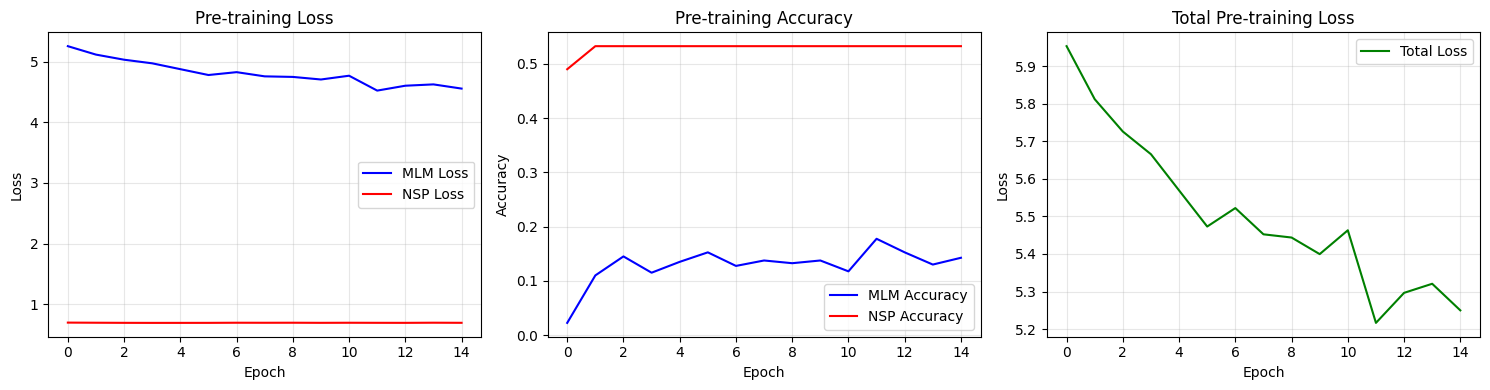

Final MLM Accuracy: 0.142
Final NSP Accuracy: 0.532


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(mlm_losses, label='MLM Loss', color='blue')
axes[0].plot(nsp_losses, label='NSP Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Pre-training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(mlm_accs, label='MLM Accuracy', color='blue')
axes[1].plot(nsp_accs, label='NSP Accuracy', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Pre-training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].plot(total_losses, label='Total Loss', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Total Pre-training Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bert_pretraining_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Final MLM Accuracy: {mlm_accs[-1]:.3f}')
print(f'Final NSP Accuracy: {nsp_accs[-1]:.3f}')

### MLM Prediction Demo

Let us see what the pre-trained model predicts for masked tokens.

In [13]:
def predict_masked_tokens(model, sentence, vocab, id_to_word, device, max_len=64):
    model.eval()
    tokens = sentence.lower().split()
    token_ids = encode_tokens(tokens, vocab)
    mask_pos = len(token_ids) - 1
    original = token_ids[mask_pos]
    token_ids[mask_pos] = MASK_ID
    input_ids = [CLS_ID] + token_ids + [SEP_ID]
    segment_ids = [0] * len(input_ids)
    attn_mask = [1] * len(input_ids)
    while len(input_ids) < max_len:
        input_ids.append(PAD_ID)
        segment_ids.append(PAD_ID)
        attn_mask.append(0)
    input_ids = torch.tensor([input_ids], dtype=torch.long).to(device)
    segment_ids = torch.tensor([segment_ids], dtype=torch.long).to(device)
    attn_mask = torch.tensor([attn_mask], dtype=torch.long).to(device)
    with torch.no_grad():
        mlm_logits, _ = model(input_ids, segment_ids, attn_mask)
    pos = mask_pos + 1
    probs = F.softmax(mlm_logits[0, pos], dim=-1)
    top5 = torch.topk(probs, 5)
    original_word = id_to_word.get(original, '?')
    print(f'Sentence: {" ".join(tokens[:-1])} [___]')
    print(f'Original: {original_word}')
    print(f'Top-5 predictions:')
    for i, (prob, idx) in enumerate(zip(top5.values, top5.indices)):
        word = id_to_word.get(idx.item(), '?')
        marker = ' <-' if idx.item() == original else ''
        print(f'  {i+1}. {word:15s} (p={prob:.4f}){marker}')
    print()

test_sentences = [
    'the cat sat on the mat',
    'the sun rises in the east',
    'the boy built a tall tower',
    'rain fell from the sky',
    'she writes the answer down',
]
for sent in test_sentences:
    predict_masked_tokens(model, sent, vocab, id_to_word, DEVICE, MAX_LEN)

Sentence: the cat sat on the [___]
Original: mat
Top-5 predictions:
  1. the             (p=0.0428)
  2. he              (p=0.0181)
  3. tower           (p=0.0144)
  4. everyone        (p=0.0104)
  5. she             (p=0.0103)

Sentence: the sun rises in the [___]
Original: east
Top-5 predictions:
  1. the             (p=0.0432)
  2. he              (p=0.0183)
  3. tower           (p=0.0144)
  4. everyone        (p=0.0104)
  5. she             (p=0.0103)

Sentence: the boy built a tall [___]
Original: tower
Top-5 predictions:
  1. the             (p=0.0423)
  2. he              (p=0.0183)
  3. tower           (p=0.0145) <-
  4. she             (p=0.0102)
  5. everyone        (p=0.0102)

Sentence: rain fell from the [___]
Original: sky
Top-5 predictions:
  1. the             (p=0.0361)
  2. her             (p=0.0117)
  3. a               (p=0.0115)
  4. liquids         (p=0.0110)
  5. blue            (p=0.0105)

Sentence: she writes the answer [___]
Original: down
Top-5 predictions:
  

## 7. Fine-tuning on a Classification Task

After pre-training, we add a classification head on top of BERT and fine-tune ALL parameters on a small sentiment classification task. This demonstrates BERT key paradigm: pre-train on unlabelled data, fine-tune on a small labelled task.

In [14]:
positive_sentences = [
    'the cat is very happy today',
    'everyone enjoys the sunny day',
    'the family ate together happily',
    'children made snowmen outside',
    'the bird flew away one morning',
    'they played in the garden',
    'the teacher smiles at her',
    'the class is very happy',
    'flowers open their petals',
    'the food smells delicious',
    'she published her findings',
    'they took photos of it',
    'his family comes home',
    'the student thinks hard',
    'birds sing in the morning',
    'everyone drank hot chocolate',
    'she fed it every day',
    'the girl found a small bird',
    'plants drank the water happily',
    'the bird grew stronger',
]
negative_sentences = [
    'the cat ran away quickly',
    'the dog chased it outside',
    'the tower fell down suddenly',
    'it had a broken wing',
    'the car stopped at the light',
    'winter came early that year',
    'lakes froze into solid ice',
    'the river rose higher',
    'the ground became very wet',
    'rain fell from the sky',
    'the wind blows gently cold',
    'snow covered the mountains',
    'he waited patiently in rain',
    'people wore warm heavy coats',
    'birds stayed in their nests',
    'the cat looked around afraid',
    'the dog barked at the cat',
    'the mixture turned bright wrong',
    'the food smells burnt bad',
    'the student could not answer',
]
finetune_data = [(s, 1) for s in positive_sentences] + [(s, 0) for s in negative_sentences]
random.shuffle(finetune_data)
print(f'Fine-tuning dataset: {len(finetune_data)} samples ({len(positive_sentences)} pos, {len(negative_sentences)} neg)')
split_idx = int(0.8 * len(finetune_data))
train_data = finetune_data[:split_idx]
test_data = finetune_data[split_idx:]
print(f'Train: {len(train_data)}, Test: {len(test_data)}')

Fine-tuning dataset: 40 samples (20 pos, 20 neg)
Train: 32, Test: 8


In [15]:
class FinetuneDataset(Dataset):
    def __init__(self, data, vocab, max_len=64):
        self.data = data
        self.vocab = vocab
        self.max_len = max_len
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        sentence, label = self.data[idx]
        tokens = encode_tokens(tokenize(sentence), self.vocab)
        input_ids = [CLS_ID] + tokens + [SEP_ID]
        segment_ids = [0] * len(input_ids)
        attn_mask = [1] * len(input_ids)
        while len(input_ids) < self.max_len:
            input_ids.append(PAD_ID)
            segment_ids.append(PAD_ID)
            attn_mask.append(0)
        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(segment_ids, dtype=torch.long),
            torch.tensor(attn_mask, dtype=torch.long),
            torch.tensor(label, dtype=torch.long),
        )

train_ds = FinetuneDataset(train_data, vocab, MAX_LEN)
test_ds = FinetuneDataset(test_data, vocab, MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
print(f'Fine-tuning loaders ready: {len(train_loader)} train batches, {len(test_loader)} test batches')

Fine-tuning loaders ready: 4 train batches, 1 test batches


In [16]:
class BERTForClassification(nn.Module):
    def __init__(self, bert_model, n_classes=2, dropout=0.1):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.d_model, n_classes)
    def forward(self, input_ids, segment_ids, attention_mask=None):
        sequence_output = self.bert.encode(input_ids, segment_ids, attention_mask)
        pooled = self.bert.pooler(sequence_output[:, 0])
        logits = self.classifier(self.dropout(pooled))
        return logits

clf_model = BERTForClassification(model, n_classes=2).to(DEVICE)
clf_params = sum(p.numel() for p in clf_model.parameters())
print(f'Classification model parameters: {clf_params:,}')
print('(All BERT parameters are fine-tuned end-to-end)')

Classification model parameters: 463,682
(All BERT parameters are fine-tuned end-to-end)


In [17]:
def train_finetuning(model, train_loader, test_loader, epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    train_losses = []
    train_accs = []
    test_accs = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        correct = 0
        total = 0
        n_batches = 0
        for batch in train_loader:
            input_ids, segment_ids, attn_mask, labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            logits = model(input_ids, segment_ids, attn_mask)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        avg_loss = epoch_loss / n_batches
        train_acc = correct / total
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for batch in test_loader:
                input_ids, segment_ids, attn_mask, labels = [b.to(device) for b in batch]
                logits = model(input_ids, segment_ids, attn_mask)
                preds = logits.argmax(dim=-1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
        test_acc = test_correct / max(test_total, 1)
        model.train()
        train_losses.append(avg_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f'Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}')
    return train_losses, train_accs, test_accs

print('Starting fine-tuning...')
ft_losses, ft_train_accs, ft_test_accs = train_finetuning(clf_model, train_loader, test_loader, FINETUNE_EPOCHS, LR, DEVICE)
print('Fine-tuning complete!')

Starting fine-tuning...
Epoch   1/10 | Loss: 0.7012 | Train Acc: 0.406 | Test Acc: 0.375
Epoch   2/10 | Loss: 0.6865 | Train Acc: 0.531 | Test Acc: 0.375
Epoch   3/10 | Loss: 0.6864 | Train Acc: 0.531 | Test Acc: 0.375


Epoch   4/10 | Loss: 0.6913 | Train Acc: 0.531 | Test Acc: 0.375


Epoch   5/10 | Loss: 0.6862 | Train Acc: 0.594 | Test Acc: 0.375
Epoch   6/10 | Loss: 0.6814 | Train Acc: 0.562 | Test Acc: 0.375
Epoch   7/10 | Loss: 0.6893 | Train Acc: 0.531 | Test Acc: 0.375
Epoch   8/10 | Loss: 0.6886 | Train Acc: 0.562 | Test Acc: 0.375


Epoch   9/10 | Loss: 0.6824 | Train Acc: 0.594 | Test Acc: 0.375


Epoch  10/10 | Loss: 0.6886 | Train Acc: 0.531 | Test Acc: 0.375
Fine-tuning complete!


## 8. Results and Visualisation

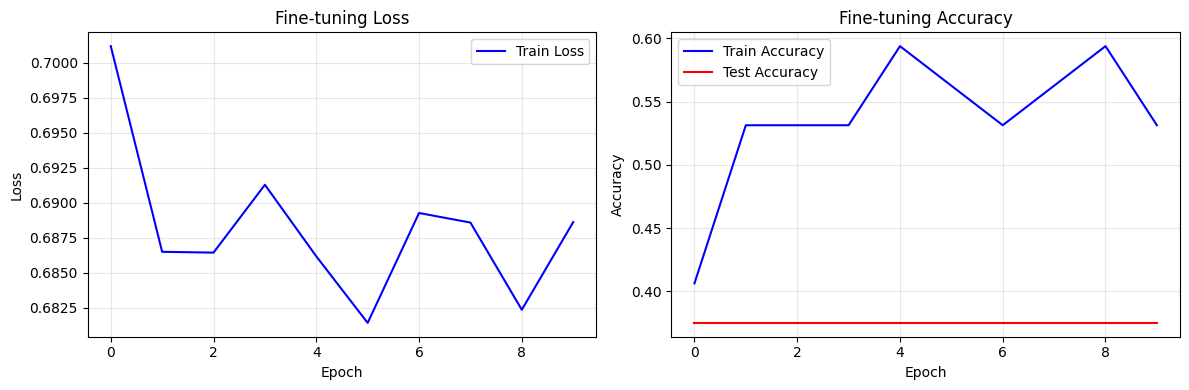

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ft_losses, label='Train Loss', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Fine-tuning Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(ft_train_accs, label='Train Accuracy', color='blue')
axes[1].plot(ft_test_accs, label='Test Accuracy', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Fine-tuning Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bert_finetuning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [19]:
print('=' * 60)
print('BERT Implementation Summary')
print('=' * 60)
print(f'Model: {N_LAYERS} layers, {D_MODEL} hidden, {N_HEADS} heads')
print(f'Vocabulary: {VOCAB_SIZE} tokens')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'')
print(f'Pre-training ({MLM_EPOCHS} epochs):')
print(f'  Final MLM Loss: {mlm_losses[-1]:.4f}')
print(f'  Final MLM Accuracy: {mlm_accs[-1]:.3f}')
print(f'  Final NSP Loss: {nsp_losses[-1]:.4f}')
print(f'  Final NSP Accuracy: {nsp_accs[-1]:.3f}')
print(f'')
print(f'Fine-tuning ({FINETUNE_EPOCHS} epochs):')
print(f'  Final Train Accuracy: {ft_train_accs[-1]:.3f}')
print(f'  Final Test Accuracy: {ft_test_accs[-1]:.3f}')
print(f'')
print('Key mechanisms demonstrated:')
print('  [OK] Masked Language Model (MLM) with 80/10/10 strategy')
print('  [OK] Next Sentence Prediction (NSP)')
print('  [OK] Bidirectional Transformer encoder (no causal mask)')
print('  [OK] Token + Segment + Position embeddings')
print('  [OK] GELU activation')
print('  [OK] Post-LN residual connections')
print('  [OK] Fine-tuning paradigm: pre-train then fine-tune all params')
print('  [OK] Weight tying between MLM decoder and token embeddings')
print('=' * 60)

BERT Implementation Summary
Model: 2 layers, 128 hidden, 4 heads
Vocabulary: 190 tokens
Parameters: 463,424

Pre-training (15 epochs):
  Final MLM Loss: 4.5582
  Final MLM Accuracy: 0.142
  Final NSP Loss: 0.6916
  Final NSP Accuracy: 0.532

Fine-tuning (10 epochs):
  Final Train Accuracy: 0.531
  Final Test Accuracy: 0.375

Key mechanisms demonstrated:
  [OK] Masked Language Model (MLM) with 80/10/10 strategy
  [OK] Next Sentence Prediction (NSP)
  [OK] Bidirectional Transformer encoder (no causal mask)
  [OK] Token + Segment + Position embeddings
  [OK] GELU activation
  [OK] Post-LN residual connections
  [OK] Fine-tuning paradigm: pre-train then fine-tune all params
  [OK] Weight tying between MLM decoder and token embeddings
